In [ ]:
import os
os.environ["HF_TOKEN"] = ""  
HF_TOKEN = os.environ.get("HF_TOKEN")
from textgrid import TextGrid
from pathlib import Path
import re
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


In [ ]:
from huggingface_hub import snapshot_download

local_dir = "/Users/romangogolev/beat1_text_only"

snapshot_download(
    repo_id="H-Liu1997/BEAT",       # BEAT1 repo
    repo_type="dataset",
    local_dir=local_dir,

    # Download ALL TextGrid files across all speaker subfolders
    allow_patterns=[
        "beat_english_v0.2.1/beat_english_v0.2.1/*/*.TextGrid"
    ]
)

print("Download completed")


Fetching ... files: 0it [00:00, ?it/s]

Download completed


In [ ]:
DIRECTION_PHRASES = [
    # --- 1 word ---
   "forward", "back", "behind", "here",
    "inside", "outside", "upstairs", "downstairs", "around","front",

    # --- 2 words ---
    "go left", "go right", "go straight", "go forward", "go back",
    "turn left", "turn right",
    "head left", "head right",
    "walk straight", "move forward",
    "over there", "right there", "just there", "right here", "over here",
    "this way", "that way",
    "next to", "in front", "behind you", "nearby location",
    "at corner", "by stairs", "near entrance",

    # --- 3 words ---
    "go to platform", "go to exit", "go to train",
    "head to exit", "walk to platform",
    "on your left", "on your right",
    "in front of", "next to platform",
    "across from entrance",
    "keep going straight", "continue going straight",
    "turn to left", "turn to right",
    "go straight ahead",
    "right over there", "just over there",
    "on this side", "on that side",
    "on the left", "on the right",
    "at the corner", "by the stairs", "near the entrance",

    # --- 4 words ---
    "go straight then left",
    "go straight then right",
    "first go straight then",
    "then turn to left",
    "then turn to right",
    "after that go left",
    "after that go right",
    "you should go left",
    "you should go right",
    "you can go straight",
    "you need to go left",
    "you need to go right",
    "walk straight to platform",
    "head straight to exit",
    "go over to platform",
    "go over to exit",
]

sample_counts = defaultdict(int)   
keyword_counts = Counter()         

textgrid_dir = Path("/Users/romangogolev/beat1_text_only/beat_english_v0.2.1/beat_english_v0.2.1")

# -------- MATCH FUNCTIONS --------
def match_keywords_upgrade(text):
    # normalize whitespace and lowercase
    text = re.sub(r"\s+", " ", text.lower().strip())

    matches = []
    # sort phrases by word count / length so longer phrases are attempted first
    phrases_sorted = sorted(DIRECTION_PHRASES, key=lambda s: (-len(s.split()), -len(s)))

    for k in phrases_sorted:
        # build pattern that allows one-or-more whitespace between words
        parts = [re.escape(p) for p in k.split()]
        pattern = rf"\b{r'\s+'.join(parts)}\b"
        for m in re.finditer(pattern, text):
            matches.append(k)
            # optional: remove matched span from text to avoid overlapping double-counts
            # start, end = m.span()
            # text = text[:start] + " " * (end - start) + text[end:]
            # break   # uncomment to only take first match of this phrase per text
    return matches

# -------- MAIN LOOP --------
# We will group contiguous word intervals into "segments" by short pauses so multi-word
# phrases that span multiple TextGrid intervals are found.
PAUSE_THRESHOLD = 0.6  # seconds: pause longer than this starts a new line/segment

for file in textgrid_dir.rglob("*.TextGrid"):
    tg = TextGrid.fromFile(str(file))

    # find 'words' tier (fallback to first interval tier if missing)
    words_tier = None
    for tier in tg.tiers:
        if tier.name.lower() == "words":
            words_tier = tier
            break
    if words_tier is None:
        for tier in tg.tiers:
            # interval tier detection: has items with .mark
            try:
                _ = [iv.mark for iv in tier]
                words_tier = tier
                break
            except Exception:
                continue
    if words_tier is None:
        continue

    # Build contiguous segments: merge consecutive non-empty words unless a pause > threshold
    segments = []  # each entry: (start_time, end_time, text)
    current_words = []
    current_start = None
    current_end = None

    for iv in words_tier:
        w = iv.mark.strip() if hasattr(iv, 'mark') else str(iv.text).strip()
        if w == "":
            # treat as silence; if we have a current segment, close it if the silence is long
            if current_words:
                # extend end to current_end
                segments.append((current_start, current_end, " ".join(current_words)))
                current_words = []
                current_start = None
                current_end = None
            continue

        # non-empty word
        if current_start is None:
            current_start = iv.minTime
            current_end = iv.maxTime
            current_words = [w]
        else:
            gap = iv.minTime - current_end
            if gap > PAUSE_THRESHOLD:
                # close previous segment
                segments.append((current_start, current_end, " ".join(current_words)))
                # start new segment
                current_start = iv.minTime
                current_end = iv.maxTime
                current_words = [w]
            else:
                # continue current segment
                current_words.append(w)
                current_end = iv.maxTime

    # flush last
    if current_words:
        segments.append((current_start, current_end, " ".join(current_words)))

    # Search each segment with upgraded matcher
    matched_any = False
    for start, end, seg_text in segments:
        found = match_keywords_upgrade(seg_text)
        if found:
            matched_any = True
            sample_counts[file.name] += len(found)
            keyword_counts.update(found)

    # (optional) also check the entire tier text as a fallback to catch matches across accidental
    # segment boundaries (but we avoid double-counting by only doing this when no segment matched)
    if not matched_any:
        full_text = " ".join([iv.mark.strip() for iv in words_tier if getattr(iv, 'mark', '').strip()])
        fallback_found = match_keywords_upgrade(full_text)
        if fallback_found:
            sample_counts[file.name] += len(fallback_found)
            keyword_counts.update(fallback_found)

# -------- RESULTS --------
print("Total samples:", len(sample_counts))
print("Top samples:", sorted(sample_counts.items(), key=lambda x: x[1], reverse=True)[:5])
print("Keyword distribution:", keyword_counts)


Total samples: 1060
Top samples: [('19_jaime_1_2_2.TextGrid', 33), ('2_scott_1_7_7.TextGrid', 27), ('6_carla_1_10_10.TextGrid', 23), ('24_kexin_1_3_3.TextGrid', 18), ('11_nidal_1_12_12.TextGrid', 17)]
Keyword distribution: Counter({'around': 682, 'back': 624, 'here': 494, 'inside': 159, 'front': 153, 'in front': 107, 'in front of': 104, 'go back': 95, 'outside': 73, 'behind': 69, 'next to': 56, 'this way': 48, 'forward': 46, 'over there': 31, 'that way': 27, 'on your right': 11, 'right there': 9, 'just there': 7, 'on your left': 7, 'on the right': 6, 'behind you': 5, 'over here': 5, 'go forward': 3, 'move forward': 3, 'on the left': 2, 'right here': 2, 'downstairs': 1})


In [27]:
sample_counts

defaultdict(int,
            {'20_li_0_9_9.TextGrid': 1,
             '20_li_0_16_16.TextGrid': 1,
             '20_li_0_7_7.TextGrid': 1,
             '20_li_0_104_104.TextGrid': 5,
             '20_li_0_88_88.TextGrid': 3,
             '20_li_1_3_3.TextGrid': 2,
             '20_li_0_103_103.TextGrid': 3,
             '20_li_0_14_14.TextGrid': 1,
             '20_li_0_6_6.TextGrid': 1,
             '20_li_0_11_11.TextGrid': 2,
             '20_li_0_1_1.TextGrid': 1,
             '20_li_0_87_87.TextGrid': 3,
             '20_li_0_111_111.TextGrid': 4,
             '20_li_0_65_65.TextGrid': 3,
             '20_li_1_1_1.TextGrid': 1,
             '20_li_0_95_95.TextGrid': 2,
             '20_li_0_5_5.TextGrid': 1,
             '20_li_1_2_2.TextGrid': 1,
             '20_li_0_13_13.TextGrid': 1,
             '18_daiki_0_11_11.TextGrid': 2,
             '18_daiki_1_1_1.TextGrid': 4,
             '18_daiki_0_6_6.TextGrid': 2,
             '18_daiki_0_87_87.TextGrid': 4,
             '18_da

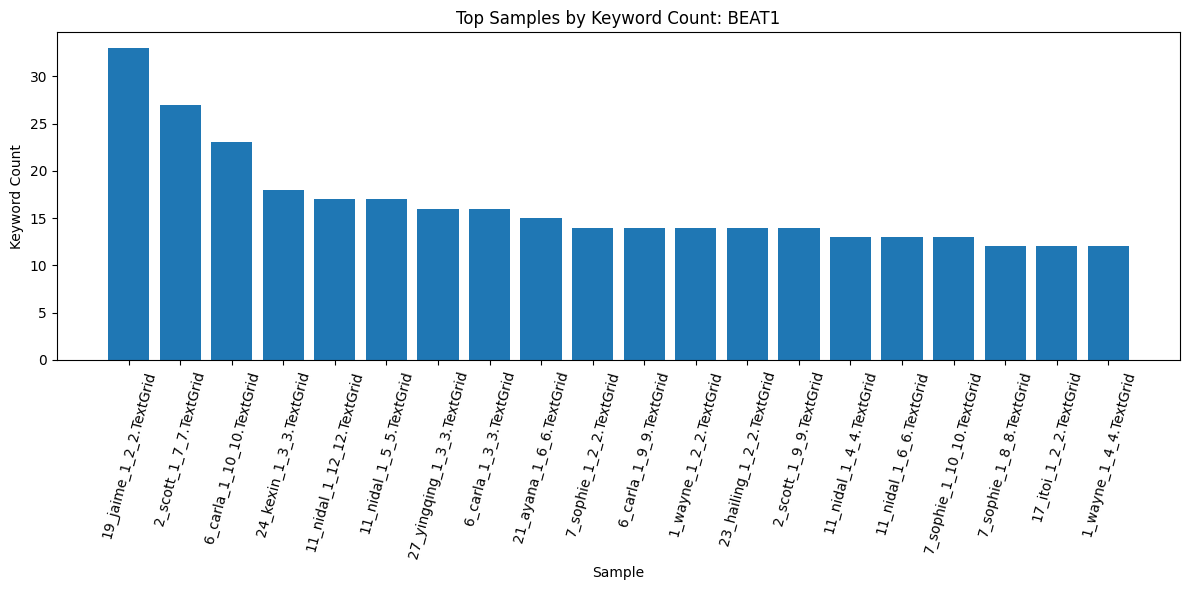

In [21]:
# sort samples
top_samples = sorted(sample_counts.items(), key=lambda x: x[1], reverse=True)[:20]

labels = [s for s, _ in top_samples]
counts = [c for _, c in top_samples]

plt.figure(figsize=(12, 6))
plt.bar(labels, counts)

plt.title("Top Samples by Keyword Count: BEAT1")
plt.xlabel("Sample")
plt.ylabel("Keyword Count")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

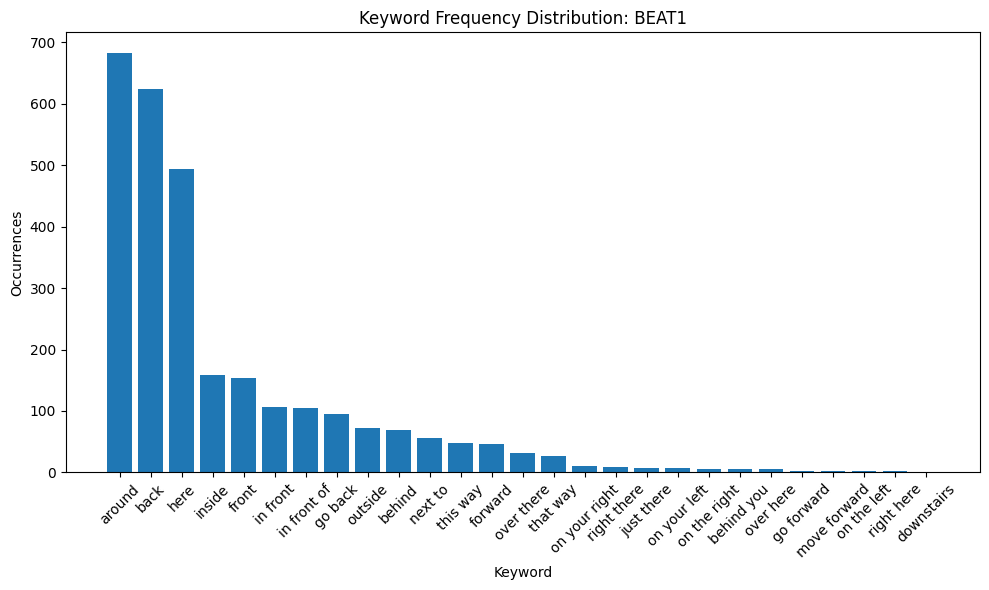

In [26]:
# sort keywords
sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)

labels = [k for k, _ in sorted_keywords]
counts = [c for _, c in sorted_keywords]

plt.figure(figsize=(10, 6))
plt.bar(labels, counts)

plt.title("Keyword Frequency Distribution: BEAT1")
plt.xlabel("Keyword")
plt.ylabel("Occurrences")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## In the next cells we are collecting bvh and wav files for samples where more than 5 words occur. It was performed to gain valid samples. However, this approach didn't work out. Gained samples do not cover our use case. 

In [24]:
MIN_KEYWORDS = 5

sample_ids = [
    s.replace(".TextGrid", "")
    for s, count in sample_counts.items()
    if count >= MIN_KEYWORDS
]

print("Samples to download:", len(sample_ids))
print(sample_ids[:5])

Samples to download: 119
['20_li_0_104_104', '18_daiki_1_2_2', '27_yingqing_1_3_3', '27_yingqing_0_104_104', '9_miranda_1_10_10']


In [25]:
patterns = []

# BEAT1: files are at beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sample_id}.bvh
# Extract speaker_id from sample filename: e.g. "1_wayne_0_100_100" → speaker_id = "1"
for sid in sample_ids:
    speaker_id = sid.split("_")[0]
    patterns.append(f"beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sid}.bvh")

# OPTIONAL: audio (same folder structure)
for sid in sample_ids:
    speaker_id = sid.split("_")[0]
    patterns.append(f"beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sid}.wav")

print(f"Total patterns: {len(patterns)}")
print("Example:", patterns[:2])


Total patterns: 238
Example: ['beat_english_v0.2.1/beat_english_v0.2.1/20/20_li_0_104_104.bvh', 'beat_english_v0.2.1/beat_english_v0.2.1/18/18_daiki_1_2_2.bvh']


In [13]:
from huggingface_hub import snapshot_download

local_dir = "/Users/romangogolev/beat1_selected"

snapshot_download(
    repo_id="H-Liu1997/BEAT",       # BEAT1 repo
    repo_type="dataset",
    local_dir=local_dir,
    allow_patterns=patterns
)

print("Download completed")


Fetching ... files: 0it [00:00, ?it/s]

Download completed


In [15]:
from pathlib import Path

# -------- CONFIG --------
# BEAT1: BVH files are nested in per-speaker subfolders
base_dir = Path("/Users/romangogolev/beat1_selected/beat_english_v0.2.1/beat_english_v0.2.1")

# -------- COLLECT --------
results = []

# Use rglob to find BVH files across all speaker subfolders
for bvh_file in base_dir.rglob("*.bvh"):
    try:
        # Count frames by reading the BVH header (fast, no full parse needed)
        frames = 0
        with open(bvh_file, "r") as f:
            for line in f:
                line = line.strip()
                if line.startswith("Frames:"):
                    frames = int(line.split(":")[1].strip())
                    break

        sample_id = bvh_file.stem
        results.append((sample_id, frames))

    except Exception as e:
        print(f"Error reading {bvh_file.name}: {e}")

# -------- SORT --------
results.sort(key=lambda x: x[1])  # by frames ascending

# -------- TOP 5 --------
top5 = results[:5]

print(f"Total BVH files found: {len(results)}")
print("\nTop-5 smallest samples:")
for sample_id, frames in top5:
    print(f"  {sample_id} → {frames} frames")


Error reading 30_katya_1_1_1.bvh: invalid literal for int() with base 10: '74437.0'
Error reading 14_zhang_1_2_2.bvh: invalid literal for int() with base 10: '71940.0'
Total BVH files found: 71

Top-5 smallest samples:
  8_catherine_0_84_84 → 4680 frames
  7_sophie_0_84_84 → 5520 frames
  16_jorge_0_111_111 → 6000 frames
  1_wayne_0_84_84 → 6240 frames
  4_lawrence_0_84_84 → 8040 frames


In [16]:
results

[('8_catherine_0_84_84', 4680),
 ('7_sophie_0_84_84', 5520),
 ('16_jorge_0_111_111', 6000),
 ('1_wayne_0_84_84', 6240),
 ('4_lawrence_0_84_84', 8040),
 ('11_nidal_0_84_84', 8520),
 ('21_ayana_0_103_103', 8880),
 ('24_kexin_0_104_104', 10200),
 ('17_itoi_0_88_88', 10320),
 ('2_scott_1_2_2', 45600),
 ('2_scott_1_1_1', 50400),
 ('11_nidal_1_6_6', 65280),
 ('6_carla_1_12_12', 66360),
 ('1_wayne_1_4_4', 67440),
 ('24_kexin_1_2_2', 69613),
 ('2_scott_1_8_8', 70440),
 ('11_nidal_1_3_3', 71160),
 ('19_jaime_1_2_2', 71170),
 ('27_yingqing_1_3_3', 71258),
 ('4_lawrence_1_3_3', 71280),
 ('2_scott_1_11_11', 71640),
 ('2_scott_1_12_12', 71640),
 ('15_carlos_1_2_2', 71982),
 ('7_sophie_1_11_11', 72000),
 ('1_wayne_1_5_5', 72000),
 ('1_wayne_1_1_1', 72000),
 ('1_wayne_1_3_3', 72000),
 ('8_catherine_1_1_1', 72000),
 ('3_solomon_1_1_1', 72000),
 ('12_zhao_1_2_2', 72083),
 ('16_jorge_1_1_1', 72440),
 ('8_catherine_1_4_4', 72480),
 ('21_ayana_1_8_8', 72480),
 ('19_jaime_1_1_1', 72749),
 ('7_sophie_1_2_2'

## From our view, another approach is better: to make short extract from samples in which keywords were occurred.

In [28]:
# Collect multi-word keyword windows per sample: [sample_id, phrase, frame_rate_min, frame_rate_max]
from pathlib import Path
from textgrid import TextGrid
import re

# Config
TEXTGRID_DIR = Path("/Users/romangogolev/beat1_text_only/beat_english_v0.2.1/beat_english_v0.2.1")
PAUSE_THRESHOLD = 0.6  # seconds
PADDING = 5.0          # seconds padding before/after

# Ensure DIRECTION_PHRASES exists; fall back to the list in this cell if not
try:
    D_PHRASES = DIRECTION_PHRASES
except NameError:
    D_PHRASES = DIRECTION_PHRASES = [
        # minimal fallback (you likely already have the full list)
        "go left", "go right", "one time i was in vietnam"
    ]

# Helper: find multi-word phrases in a text (returns list of phrase strings)
def find_multiword_phrases(text, phrases):
    txt = re.sub(r"\s+", " ", text.lower().strip())
    results = []
    phrases_sorted = sorted(phrases, key=lambda s: (-len(s.split()), -len(s)))
    for k in phrases_sorted:
        if len(k.split()) < 2:
            continue
        parts = [re.escape(p) for p in k.split()]
        pattern = rf"\b{r'\s+'.join(parts)}\b"
        for m in re.finditer(pattern, txt):
            results.append(k)
    return results

# Output array
candidate_windows = []  # list of [sample_id, phrase, start_sec, end_sec]

for tg_file in TEXTGRID_DIR.rglob("*.TextGrid"):
    try:
        tg = TextGrid.fromFile(str(tg_file))
    except Exception:
        continue

    # find words tier
    words_tier = None
    for t in tg.tiers:
        if getattr(t, 'name', '').lower() == 'words':
            words_tier = t
            break
    if words_tier is None:
        # fallback to first interval-like tier
        for t in tg.tiers:
            try:
                _ = [iv.mark for iv in t]
                words_tier = t
                break
            except Exception:
                continue
    if words_tier is None:
        continue

    # compute audio / tier duration (use max end time)
    try:
        duration = max(iv.maxTime for iv in words_tier)
    except Exception:
        duration = None

    # build segments of contiguous words separated by pauses > PAUSE_THRESHOLD
    segments = []  # (start, end, text)
    cur_words = []
    cur_start = None
    cur_end = None

    for iv in words_tier:
        w = iv.mark.strip() if hasattr(iv, 'mark') else str(getattr(iv, 'text', '')).strip()
        if w == "":
            if cur_words:
                segments.append((cur_start, cur_end, " ".join(cur_words)))
                cur_words = []
                cur_start = cur_end = None
            continue

        if cur_start is None:
            cur_start = iv.minTime
            cur_end = iv.maxTime
            cur_words = [w]
        else:
            gap = iv.minTime - cur_end
            if gap > PAUSE_THRESHOLD:
                segments.append((cur_start, cur_end, " ".join(cur_words)))
                cur_start = iv.minTime
                cur_end = iv.maxTime
                cur_words = [w]
            else:
                cur_words.append(w)
                cur_end = iv.maxTime

    if cur_words:
        segments.append((cur_start, cur_end, " ".join(cur_words)))

    sample_id = tg_file.stem

    # search each segment for multi-word phrases
    for seg_start, seg_end, seg_text in segments:
        found = find_multiword_phrases(seg_text, D_PHRASES)
        for phrase in found:
            start_win = max(0.0, (seg_start - PADDING) if seg_start is not None else 0.0)
            end_win = (seg_end + PADDING) if seg_end is not None else None
            if duration is not None and end_win is not None:
                end_win = min(end_win, duration)
            # append [sample_id, phrase, start_sec, end_sec]
            candidate_windows.append([sample_id, phrase, round(start_win, 3), round(end_win if end_win is not None else start_win + PADDING, 3)])

# summary
print(f"Collected {len(candidate_windows)} windows (multi-word phrases).")
print("First 20 entries:")
for item in candidate_windows[:20]:
    print(item)

# keep candidate_windows in notebook namespace for later use


Collected 525 windows (multi-word phrases).
First 20 entries:
['20_li_0_7_7', 'this way', 71.2, 83.29]
['20_li_0_104_104', 'over there', 53.57, 65.11]
['20_li_0_87_87', 'in front of', 79.47, 92.55]
['20_li_0_87_87', 'in front', 79.47, 92.55]
['20_li_0_65_65', 'in front of', 29.15, 41.68]
['20_li_0_65_65', 'in front', 29.15, 41.68]
['20_li_1_1_1', 'that way', 115.05, 128.77]
['18_daiki_0_87_87', 'in front of', 77.96, 90.76]
['18_daiki_0_87_87', 'in front', 77.96, 90.76]
['18_daiki_0_65_65', 'in front of', 12.61, 24.11]
['18_daiki_0_65_65', 'in front', 12.61, 24.11]
['18_daiki_1_2_2', 'go back', 565.24, 577.35]
['18_daiki_0_73_73', 'in front', 14.0, 25.07]
['18_daiki_0_7_7', 'this way', 61.02, 71.8]
['18_daiki_0_10_10', 'go forward', 42.74, 55.19]
['18_daiki_0_82_82', 'next to', 57.88, 69.98]
['27_yingqing_1_2_2', 'this way', 233.36, 246.07]
['27_yingqing_0_87_87', 'in front of', 77.62, 89.59]
['27_yingqing_0_87_87', 'in front', 77.62, 89.59]
['27_yingqing_1_3_3', 'in front of', 366.6, 3

In [29]:
import csv
out_path = "/Users/romangogolev/beat1_candidate_windows.csv"

with open(out_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["sample_id", "phrase", "start_sec", "end_sec"])
    for sample_id, phrase, start, end in candidate_windows:
        writer.writerow([sample_id, phrase, start, end])

print("Saved CSV:", out_path)

Saved CSV: /Users/romangogolev/beat1_candidate_windows.csv


## Now we got a valuable table with information which part of each sample to extract. However, it would be reprocessed by another script to get rid of duplicates.